<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/Gradientenabstieg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Das Gradientenverfahren bei der linearen Regression

In diesem Notebook wollen wir die lineare Regression mit Hilfe des Gradientenverfahrens implementieren. Dabei werden wir schrittweise das Modell, die Kostenfunktion, die Gradientenberechnung und den Optimierungsalgorithmus als Python-Funktionen formulieren und testen.

## Import und Vorbereitung
Zunächst importieren wir die benötigten Pakete.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

## Beispiel-Datensatz
Wir erzeugen einen synthetischen Datensatz, der sich gut durch eine lineare Funktion beschreiben lässt. Wir simulieren einen linearen Zusammenhang mit etwas Rauschen:

$$ y = 4 + 3x + \epsilon $$

In [2]:
# Beispielhafte Daten
np.random.seed(42)
m = 100 #Anzahl der Datenpunkte
X = 2 * np.random.rand(m, 1) #erzeugt eine Matrix mit 100 Zeilen und 1 Spalte. Die Werte sind gleichverteilt im Intervall (0,1), aber mit *2 (0,2) Intervall
y = 4 + 3 * X + np.random.randn(m, 1) #Formel + rauschen / np.random.randn(m, 1) =  normalverteilte Zufallszahlen mit Mittelwert 0 und Standardabweichung 1

# Bias-Term ergänzen
X_b = np.c_[np.ones((m, 1)), X]  # X0 = 1 für Bias
y = y.reshape(-1, 1) #Mach daraus eine Matrix mit 1 Spalte, und die Anzahl der Zeilen rechnest du dir selbst aus.

    np.ones((m, 1))

Erzeugt eine Matrix der Form (100, 1) voller Einsen. # nur einsen

X ist die schon vorhandene Spaltenmatrix mit den x-Werten, ebenfalls Form (100,1) #Die x-werte

np.c_ ist eine NumPy-Kurzschreibweise für klebe Spalten nebeneinander. Es nimmt mehrere Arrays und fügt sie spaltenweise zu einer neuen Matrix zusammen.

Das sind zwei verschiedene Sorten: w wird mit x multipliziert, b steht allein. Im Code müsste man die getrennt behandeln – getrennte Update-Regeln, getrennte Gradienten, das wird unübersichtlich.

Warum? Für einheitliche Struktur.

    y = w0 * 1 + w1 * x

## Modellfunktion
Wir betrachten eine lineare Modellfunktion der Form:
$$ \hat{y} = X\theta $$
**Aufgabe:*** Schreibe eine Funktion `predict(X, theta)`, die für eine gegebene Datenmatrix `X` und Parametervektor `theta` die Vorhersage berechnet.

In [3]:
def predict(X, theta):

    """Berechnet die Modellvorhersage durch lineare Regression."""

    ergebnis = X @ theta

    return ergebnis


   # raise NotImplementedError()

In [4]:
# Test
theta_test = np.array([[4], [3]])
y_pred = predict(X_b, theta_test)
assert y_pred.shape == (100, 1), 'Falsches Format der Ausgabe'
assert np.allclose(y_pred[0], 4 + 3 * X[0]), 'Fehler in der Vorhersagefunktion'

## Kostenfunktion
Als Fehlermaß verwenden wir die mittlere quadratische Abweichung (MSE):
$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2 $$
**Aufgabe:** Implementiere eine Funktion `cost(X, y, theta)`, die diese Kosten berechnet.

In [5]:
def cost(X, y, theta):

  ergebnis = predict(X,theta) - y # y' - y

  ergebnis = ergebnis **2 # (y'- y)^2

  ergebnis = np.sum(ergebnis) # Summe aller Elemente in der Matrix

  ergebnis = ergebnis / (2* len(X)) # sum / 2 * n

  return ergebnis

    #"""Berechnet die mittlere quadratische Abweichung."""


In [6]:
# Test
assert np.isclose(cost(X_b, y, theta_test), 0.5 * np.mean((y_pred - y)**2))

## Gradientenberechnung
Für das Gradientenverfahren benötigen wir den Gradienten der Kostenfunktion:
$$ \nabla J(\theta) = \frac{1}{m} X^T(X\theta - y) $$
**Aufgabe:** Implementiere eine Funktion `compute_gradient(X, y, theta)`, die den Gradienten berechnet.

In [9]:
def compute_gradient(X, y, theta):
    """Berechnet den Gradienten der Kostenfunktion."""

    ergebnis = predict(X, theta) - y          # Fehler: (Xθ - y), Form (100, 1)
    ergebnis = np.transpose(X) @ ergebnis     # X^T @ Fehler, Form (2, 1)
    ergebnis = ergebnis / len(X)              # durch m teilen

    return ergebnis


    # YOUR CODE HERE
    #raise NotImplementedError()

In [10]:
# Test
grad = compute_gradient(X_b, y, theta_test)
assert grad.shape == theta_test.shape

## Gradientenverfahren
Jetzt können wir das Gradientenverfahren implementieren. In jeder Iteration berechnen wir den Gradienten und aktualisieren die Parameter:
$$ \theta := \theta - \alpha \cdot \nabla J(\theta) $$
**Aufgabe:** Vervollständige die Funktion `gradient_descent(X, y, alpha, n_iter)`, die die Parameter iterativ verbessert.

In [13]:
def gradient_descent(X, y, alpha=0.1, n_iter=100):
    """Führt das Gradientenverfahren durch."""
    m, n = X.shape # bsp : (2, 3) 2 zeilen und 3 spalten
    theta = np.zeros((n, 1)) #zweidimensionales Array mit n Zeilen und 1 Spalte, also einen Spaltenvektor voller Nullen
    cost_history = []
    theta_history = []
    for _ in range(n_iter): # 100 mal
        theta_history.append(theta.copy()) #was ist die aktuelle theta, also (starthöhe, steigung)

        # 1. Berechne den Gradienten
        ergebnis = compute_gradient(X,y,theta) #theta ist am anfang 0 , 0

        # 2. Aktualisiere Theta
        theta = theta - alpha * ergebnis

        #raise NotImplementedError()
        cost_history.append(cost(X, y, theta))
    return theta, cost_history, theta_history

In [14]:
# Test
theta_gd, hist, hist_t = gradient_descent(X_b, y, alpha=0.1, n_iter=100)
assert len(hist) == 100
assert theta_gd.shape == (2, 1)

## Visualisierung des Kostenverlaufs

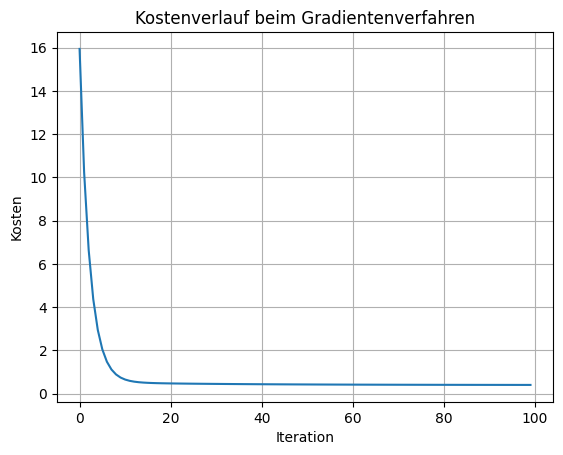

In [15]:
plt.plot(hist)
plt.xlabel("Iteration")
plt.ylabel("Kosten")
plt.title("Kostenverlauf beim Gradientenverfahren")
plt.grid()
plt.show()

Die Kurve zeigt die Kosten (also "wie schlecht ist die Linie") über die 100 Iterationen hinweg:

Bei Iteration 0: Kosten ≈ 16. Das ist der Start – theta war [0, 0], also eine flache Nulllinie. Sehr schlechte Schätzung, hohe Kosten.

Iterationen 0 bis ~15: Die Kurve fällt steil ab. Hier passiert das meiste Lernen. Das Verfahren dreht die zwei Regler kräftig in die richtige Richtung, die Linie nähert sich schnell den Datenpunkten an.

Ab ~Iteration 20: Die Kurve wird flach und liegt bei knapp über 0. Das Verfahren ist konvergiert – es hat das Optimum praktisch erreicht. Weitere Runden verbessern kaum noch etwas, weil die Linie schon fast perfekt sitzt.

## Modellvisualisierung
Wir zeichnen die Regressionsgerade zusammen mit den Trainingsdaten.

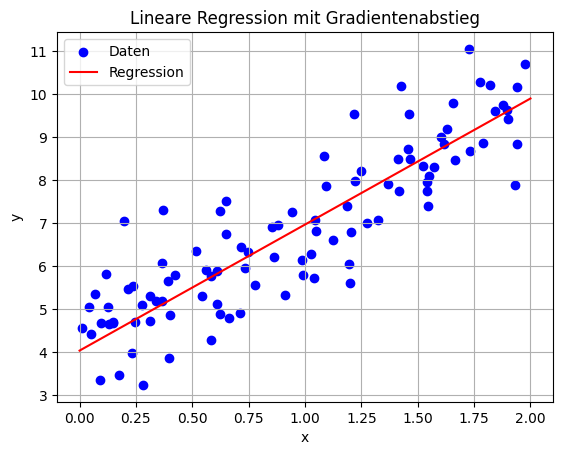

In [16]:
plt.scatter(X[:, 0], y, color="blue", label="Daten")
x_vals = np.linspace(0, 2, 100).reshape(-1, 1)
x_plot = np.c_[np.ones((100, 1)), x_vals]
plt.plot(x_vals, predict(x_plot, theta_gd), color="red", label="Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.title("Lineare Regression mit Gradientenabstieg")
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

iterations = 20

# Plot vorbereiten
fig, ax = plt.subplots()
sc = ax.scatter(X, y, label="Daten")
line, = ax.plot([], [], "r-", label="Regression")
ax.set_xlim(0, 2)
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Lineare Regression – Gradientenschritte")
ax.legend()
ax.grid()

# Animationsfunktion
def update(i):
    t = hist_t[i]
    x_vals = np.linspace(0, 2, 100).reshape(-1, 1)
    x_plot = np.c_[np.ones((100, 1)), x_vals]
    y_vals = predict(x_plot, t)
    line.set_data(x_vals, y_vals)
    ax.set_title(f"Iteration {i+1}")
    return line,

# Animation erzeugen
ani = FuncAnimation(fig, update, frames=iterations, interval=500, blit=True)
plt.close()  # Verhindert Doppelanzeige im Notebook

# Animation anzeigen
HTML(ani.to_jshtml())